# Figure S6 — FGA variant growth-rate inference (representative run)

FGA counterpart of figure 4 for run 14, on the SAME example windows. FGA did not converge at
window E (tropics 2032-10-01), so this renders two versions for comparison: the original E, and a
converged replacement (`REPLACEMENT_E`). Pick one for the S6 `\includegraphics`. Writes to
`reviews/round1/figures/`.


In [1]:
import sys
sys.path.append("..")  # repo root on path so antigentools imports under any kernel (VSCode).

import glob
import json
import random
from typing import Optional, List, Dict, Any

import pandas as pd
import numpy as np
import evofr as ef
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import seaborn as sns

from antigentools.utils import get_deme_stats, get_outliers
from antigentools.analysis import get_filtered_growth_rates_df, filter_growth_rates
from antigentools.plot import (
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_cases,
    get_analysis_window,
    print_window_stats,
)
from antigentools.publication_style import (
    apply_publication_styling_to_figure,
    style_figure_for_publication,
    PublicationFigureStyler,
    publication_style,
)

# Growth-rate filtering constants (match fig-4).
CONNECT_GAPS = True
MIN_SEGMENT_LENGTH = 3
MIN_SEQUENCE_COUNT = 10
MIN_VARIANT_FREQUENCY = 0.01
MIN_VARIANT_INCIDENCE = 50.0
EPSILON = 1e-3
MIN_TOTAL_SEQUENCES = 300
CONVERGENCE_THRESHOLD = 0.5

# Representative run (run 14). Data + scp'd estimates staged at the batch root, so `build`
# resolves both ../data/<build>/ and ../results/<build>/estimates/. flu-final is in git history.
build = "2026-07-04-reviewer-runs"
print(f"Analysis configuration for build: {build}")

# Font sizes come from the shared supplement convention, scaled to this
# figure's canvas. This figure is drawn ~30in wide against ~12in for the
# aggregated panels, so copying the raw sizes would leave its labels
# reaching the printed page at roughly a third the size of the others.
from antigentools.supplement_style import scale_for_canvas

S6_CANVAS_WIDTH_IN = 30.0
S6_SIZES = scale_for_canvas(S6_CANVAS_WIDTH_IN)


/Users/zo/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analysis configuration for build: 2026-07-04-reviewer-runs


In [2]:
# Load truth data.
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")

# Run 14's results are nested (not flattened like its data), so read the errors file by its
# explicit per-run path.
variant_growth_rates_scores_path = "../results/2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_14/variant_growth_rates.tsv"
variant_growth_rate_errors_all = pd.read_csv(variant_growth_rates_scores_path, sep="\t")
variant_growth_rate_errors_all["log_mae"] = np.log(variant_growth_rate_errors_all["mae"] + 1e-6)
variant_growth_rate_errors_all["log_mse"] = np.log(variant_growth_rate_errors_all["mse"] + 1e-6)

# Converged-only view drives the boxplot distribution (matches the GARW figure). The full view
# (`..._all`) is used by the FGA figure to force-circle a deliberately-included non-converged window.
variant_growth_rate_errors_df = variant_growth_rate_errors_all[variant_growth_rate_errors_all["converged"] == True]
print(f"Error rows: {len(variant_growth_rate_errors_all)} total, {len(variant_growth_rate_errors_df)} converged")


Error rows: 464 total, 235 converged


In [3]:
# Deme palette.
deme_palette = {
    "tropics": "#3498db",
    "north": "#e67e22",
    "south": "#2ecc71",
}

# Variant color map: use the saved auspice map if present, else derive one from the run's tips
# (run 14 has no per-run auspice map). Panels index color_map[v_name] directly and v_name may be
# int or str, so key the map on both forms.
import os
import matplotlib.colors as mcolors


def create_variant_color_map(tips_df, variant_col="variant_ag", time_col="year"):
    order = tips_df.groupby(variant_col)[time_col].min().sort_values().index.tolist()
    golden = 0.618033988749895
    colors = []
    for i in range(len(order)):
        hue = (i * golden) % 1.0
        sat, val = [(0.9, 0.95), (0.7, 0.85), (0.85, 0.75)][i % 3]
        colors.append(mcolors.rgb2hex(mcolors.hsv_to_rgb([hue, sat, val])))
    return {v: colors[i] for i, v in enumerate(order)}


color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
if os.path.exists(color_map_path):
    color_map_df = pd.read_csv(color_map_path, sep="\t")
    _cm = dict(zip(color_map_df["TRAIT_VALUE"], color_map_df["HEX_CODE"]))
else:
    _tips = pd.read_csv(f"../data/{build}/tips_with_variants.tsv", sep="\t")
    _cm = create_variant_color_map(_tips, "variant_ag", "year")

color_map = {}
for k, v in _cm.items():
    color_map[int(k)] = v
    color_map[str(k)] = v
color_map_str = {str(k): v for k, v in _cm.items()}
print(f"Created color map with {len(_cm)} variants")


Created color map with 30 variants


In [4]:
# Helper functions adapted from manuscript-figure-6 for growth rate plotting

def plot_observed_cases_clean(ax, evo_dict, location, pivot_idx=None, label_fontsize=S6_SIZES["label"]):
    """Plot observed cases histogram - clean version without legend."""
    t = np.arange(0, evo_dict[location].cases.shape[0])
    
    # Only plot data up to pivot if specified
    if pivot_idx:
        pivot_t = pivot_idx[0]
        # Filter cases to training window
        t_train = t[t <= pivot_t]
        cases_train = evo_dict[location].cases[t <= pivot_t]
    else:
        t_train = t
        cases_train = evo_dict[location].cases
    
    ax.bar(t_train, cases_train, width=5.0, color='black', alpha=0.5)
    
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    ax.set_ylabel("Cases per 100k", fontsize=label_fontsize, fontweight='normal')


def plot_frequencies_nowcast_only(
    ax: plt.Axes, 
    ef_data: Dict[str, Any], 
    freqs: pd.DataFrame, 
    deme: str, 
    model: str, 
    color_map: Dict[str, str], 
    p: int = 50, 
    pivot_idx: Optional[List[int]] = None,
    label_fontsize: int = S6_SIZES["label"]
) -> None:
    """Plot observed and nowcast frequencies of variants (training window only) - no legend."""
    # Get variant names
    v_names = sorted(ef_data[deme].var_names)
    n_variant = len(v_names)
    
    # Calculate observed frequencies
    obs_freq = np.divide(ef_data[deme].seq_counts, ef_data[deme].seq_counts.sum(axis=1)[:, None])
    t = np.arange(0, obs_freq.shape[0])

    # Grab predicted frequencies of interest
    deme_freq = freqs.query(f'location == "{deme}" and model == "{model}"')
    
    for variant in range(n_variant):
        v_name = v_names[variant]
        variant_df = deme_freq.query(f'variant == {v_name}')
        
        # Only plot data up to pivot index
        if pivot_idx:
            pivot_t = pivot_idx[0]
            # Filter observed frequencies to training window
            train_mask = t <= pivot_t
            t_train = t[train_mask]
            obs_freq_train = obs_freq[train_mask, variant]
            
            # Filter nowcast data to training window
            variant_df_train = variant_df[variant_df['t'] <= pivot_t]
        else:
            t_train = t
            obs_freq_train = obs_freq[:, variant]
            variant_df_train = variant_df
        
        # Plot observed frequencies (no label to avoid legend)
        ax.scatter(t_train, obs_freq_train, color=color_map[v_name], 
                  alpha=0.9, s=80, edgecolors='black', linewidth=0.5, zorder=5)
        
        # Plot nowcasts (no label to avoid legend)
        if not variant_df_train.empty:
            ax.plot(variant_df_train['t'], variant_df_train['median_freq_nowcast'], 
                   lw=2.5, color=color_map[v_name], zorder=4)
            ax.fill_between(variant_df_train['t'], 
                          variant_df_train[f'freq_lower_{p}'], 
                          variant_df_train[f'freq_upper_{p}'], 
                          color=color_map[v_names[variant]], alpha=0.2, zorder=1)
    
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    ax.set_ylabel("Frequency", fontsize=label_fontsize, fontweight='normal')
    ax.set_ylim(0, 1.05)


def plot_variant_incidence(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=S6_SIZES["label"]):
    """Plot variant incidence calculated from growth rates data - no legend."""
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No incidence data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Variant Incidence', fontsize=label_fontsize, fontweight='normal')
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot incidence for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty or 'variant_incidence_smoothed' not in variant_data.columns:
            continue
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Map week_start dates to t values using the evofr date mapping
        t_values = []
        incidence_values = []
        
        for idx, row in variant_data.iterrows():
            week_date = row['week_start_norm']
            # Find the closest date in our evofr date mapping
            if week_date in date_to_t:
                t_val = date_to_t[week_date]
            else:
                # Find closest date if exact match not found
                date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                if date_diffs:
                    min_diff, closest_date = min(date_diffs)
                    if min_diff <= 7:  # Only include if within a week
                        t_val = date_to_t[closest_date]
                    else:
                        continue
                else:
                    continue
            
            # Only include data up to pivot if specified
            if pivot_idx and t_val > pivot_idx[0]:
                continue
                
            t_values.append(t_val)
            incidence_values.append(row['variant_incidence_smoothed'])
        
        if not t_values:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Plot as scatter (no label to avoid legend)
        ax.scatter(t_values, incidence_values, 
                alpha=0.9, s=80, color=variant_color,
                          edgecolors='black', linewidth=0.5, zorder=5)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    # Set labels and formatting
    ax.set_ylabel('Variant Incidence \n per 100k', fontsize=label_fontsize, fontweight='normal')


def plot_r_data_vs_r_model_clean(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=S6_SIZES["label"], p=95):
    """Plot r_data (observed) vs r_model (inferred) growth rates with confidence intervals - no legend."""
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No growth rate data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Growth Rate', fontsize=label_fontsize, fontweight='normal')
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot growth rates for each variant (no legends)
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Apply filtering logic
        valid_r_data = variant_data[~variant_data['growth_rate_r_data'].isna()].copy()
        
        # Create a mapping of dates to observed data status
        observed_dates = set()
        
        # Map dates to t values and plot r_data
        if not valid_r_data.empty:
            t_values_r_data = []
            r_data_values = []
            
            for idx, row in valid_r_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:
                            t_value = date_to_t[closest_date]
                
                # Only include data up to pivot
                if t_value is not None and pd.notna(row['growth_rate_r_data']):
                    if pivot_idx and t_value > pivot_idx[0]:
                        continue
                    t_values_r_data.append(t_value)
                    r_data_values.append(row['growth_rate_r_data'])
                    observed_dates.add(week_date)  # Track observed dates
            
            # Plot observed growth rates as scatter points (no label)
            if t_values_r_data:
                ax.scatter(t_values_r_data, r_data_values, 
                          color=variant_color, alpha=0.9, s=80, 
                          edgecolors='black', linewidth=0.5, zorder=5)
        
        # For median_r, only plot at dates where we have observations
        if not variant_data.empty and not variant_data['median_r'].isna().all():
            # Filter to rows that have median_r and observed data
            model_data = variant_data[
                (~variant_data['median_r'].isna()) & 
                (variant_data['week_start_norm'].isin(observed_dates))
            ].copy()
            
            if not model_data.empty:
                # Check if confidence interval columns exist
                r_lower_col = f'r_lower_{p}'
                r_upper_col = f'r_upper_{p}'
                has_confidence_intervals = (r_lower_col in model_data.columns) and (r_upper_col in model_data.columns)
                
                t_values_r_model = []
                r_model_values = []
                r_lower_values = []
                r_upper_values = []
                
                for idx, row in model_data.iterrows():
                    week_date = row['week_start_norm']
                    t_value = None
                    
                    if week_date in date_to_t:
                        t_value = date_to_t[week_date]
                    else:
                        # Find closest date
                        date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                        if date_diffs:
                            min_diff, closest_date = min(date_diffs)
                            if min_diff <= 7:
                                t_value = date_to_t[closest_date]
                    
                    # Only include data up to pivot
                    if t_value is not None:
                        if pivot_idx and t_value > pivot_idx[0]:
                            continue
                        t_values_r_model.append(t_value)
                        r_model_values.append(row['median_r'])
                        if has_confidence_intervals:
                            r_lower_values.append(row[r_lower_col])
                            r_upper_values.append(row[r_upper_col])
                
                # Plot inferred growth rates as lines with confidence intervals
                if t_values_r_model:
                    # Sort by time
                    if has_confidence_intervals:
                        sorted_data = sorted(zip(t_values_r_model, r_model_values, r_lower_values, r_upper_values))
                        sorted_t, sorted_r, sorted_lower, sorted_upper = zip(*sorted_data) if sorted_data else ([], [], [], [])
                    else:
                        sorted_data = sorted(zip(t_values_r_model, r_model_values))
                        sorted_t, sorted_r = zip(*sorted_data) if sorted_data else ([], [])
                    
                    # Break into segments where gaps > threshold
                    segments = []
                    if sorted_t:
                        current_t = [sorted_t[0]]
                        current_r = [sorted_r[0]]
                        if has_confidence_intervals:
                            current_lower = [sorted_lower[0]]
                            current_upper = [sorted_upper[0]]
                        
                        for i in range(1, len(sorted_t)):
                            # If gap is <= 14 days (time units), continue segment
                            if sorted_t[i] - sorted_t[i-1] <= 14:
                                current_t.append(sorted_t[i])
                                current_r.append(sorted_r[i])
                                if has_confidence_intervals:
                                    current_lower.append(sorted_lower[i])
                                    current_upper.append(sorted_upper[i])
                            else:
                                # Gap detected, save segment and start new one
                                if len(current_t) >= 2:  # Only plot segments with at least 2 points
                                    if has_confidence_intervals:
                                        segments.append((current_t, current_r, current_lower, current_upper))
                                    else:
                                        segments.append((current_t, current_r))
                                current_t = [sorted_t[i]]
                                current_r = [sorted_r[i]]
                                if has_confidence_intervals:
                                    current_lower = [sorted_lower[i]]
                                    current_upper = [sorted_upper[i]]
                        
                        # Add final segment
                        if len(current_t) >= 2:
                            if has_confidence_intervals:
                                segments.append((current_t, current_r, current_lower, current_upper))
                            else:
                                segments.append((current_t, current_r))
                        
                        # Plot each segment with confidence bands
                        if has_confidence_intervals:
                            for seg_t, seg_r, seg_lower, seg_upper in segments:
                                # Plot confidence band first (behind line)
                                ax.fill_between(seg_t, seg_lower, seg_upper, 
                                              color=variant_color, alpha=0.2, zorder=1)
                                # Plot median line
                                ax.plot(seg_t, seg_r, 
                                       color=variant_color, linewidth=2.5, alpha=0.9, zorder=4)
                        else:
                            # Just plot lines without confidence bands
                            for segment in segments:
                                seg_t, seg_r = segment[0], segment[1]
                                ax.plot(seg_t, seg_r, 
                                       color=variant_color, linewidth=2.5, alpha=0.9, zorder=4)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='#666666', linestyle='--', lw=1.5, alpha=0.7, zorder=2)
    
    # Set labels and formatting
    ax.set_ylabel('Growth Rate', fontsize=label_fontsize, fontweight='normal')
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1, zorder=1)

In [5]:
def plot_combined_growth_rate_figure(
    variant_growth_rate_errors_df: pd.DataFrame,
    window_specs: List[Dict[str, str]],
    build: str,
    color_map: Dict[str, str],
    deme_palette: Dict[str, str],
    model: str = "GARW",
    fig_width: float = 30,
    fig_height: float = 20,
    boxplot_height_ratio: float = 0.3,
    title_fontsize: int = S6_SIZES["label"],
    label_fontsize: int = S6_SIZES["label"],
    tick_fontsize: int = S6_SIZES["tick"],
    panel_label_size: int = S6_SIZES["panel_letter"],
    legend_fontsize: int = S6_SIZES["legend"],
    show_main_title: bool = True,
    show_model_in_title: bool = True,
    variants_per_row: int = 3,
    p: int = 95
):
    """
    Create a combined figure with boxplot on top and growth rate windows below.
    
    Parameters:
    -----------
    variant_growth_rate_errors_df : pd.DataFrame
        DataFrame with variant growth rate error data including log_mae column
    window_specs : List[Dict[str, str]]
        List of window specifications with keys: 'pivot_date', 'location', 'model'
    build : str
        Build name
    color_map : Dict[str, str]
        Dictionary mapping variant names to colors
    deme_palette : Dict[str, str]
        Dictionary mapping deme names to colors
    model : str, default="GARW"
        Model name to filter for in boxplot
    fig_width : float, default=30
        Total figure width in inches
    fig_height : float, default=20
        Total figure height in inches
    boxplot_height_ratio : float, default=0.3
        Proportion of figure height for boxplot (0.3 = 30%)
    Returns:
    --------
    matplotlib.figure.Figure
        The created matplotlib figure
    """
    n_windows = len(window_specs)
    
    # Create figure with vertical layout: boxplot top, growth rate windows bottom
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[boxplot_height_ratio, 1-boxplot_height_ratio], hspace=0.3)
    
    # Top panel: Enhanced boxplot with highlighted points (GARW only)
    ax_boxplot = fig.add_subplot(gs[0, 0])
    
    # Filter data to only show GARW model results
    garw_data = variant_growth_rate_errors_df[variant_growth_rate_errors_df['model'] == model]
    
    # Create enhanced boxplot (from manuscript-figure-5 code) - GARW only
    boxplot = sns.boxplot(
        data=garw_data,
        x='location',  # Use location as x-axis since we only have GARW
        y='log_mae',
        order=['north', 'tropics', 'south'],
        palette=deme_palette,
        showfliers=False,
        ax=ax_boxplot,
        linewidth=1.5,
        fliersize=0
    )
    
    # Convert boxplots to outlined style for cleaner look
    for patch in boxplot.patches:
        # Get the current face color for edge color
        edge_color = patch.get_facecolor()
        # Make boxes transparent with colored edges
        patch.set_facecolor('none')
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2)
    
    # Style the boxplot lines (whiskers, medians, etc.)
    plt.setp(boxplot.lines, linewidth=1.5)
    
    # Add refined stripplot overlay and store for highlighting
    stripplot = sns.stripplot(
        data=garw_data,
        x='location',
        y='log_mae',
        order=['north', 'tropics', 'south'],
        palette=deme_palette,
        jitter=0.3,
        size=8,
        alpha=0.7,
        edgecolor='white',
        linewidth=0.5,
        legend=False,
        ax=ax_boxplot
    )
    
    # Get stripplot point positions for accurate highlighting
    stripplot_collections = stripplot.collections
    location_order = ['north', 'tropics', 'south']
    
    # Highlight points corresponding to window_specs with black circles
    for window_spec in window_specs:
        pivot_date = window_spec['pivot_date']
        location = window_spec['location']
        model = window_spec['model']
        
        # Only highlight if the model is the current model
        if model == model:
            # Find matching rows in the errors dataframe
            matching_rows = garw_data[
                (garw_data['pivot_date'] == pivot_date) &
                (garw_data['location'] == location)
            ]
            
            if not matching_rows.empty:
                # Get data grouped by location for exact position matching
                location_idx = location_order.index(location) if location in location_order else -1
                if location_idx >= 0 and location_idx < len(stripplot_collections):
                    # Get points for this location
                    collection = stripplot_collections[location_idx]
                    points = collection.get_offsets()
                    
                    # Get the location subset for this location
                    location_data = garw_data[garw_data['location'] == location].reset_index(drop=True)
                    
                    for _, row in matching_rows.iterrows():
                        # Find the index of this point in the location subset
                        match_mask = (
                            (location_data['pivot_date'] == pivot_date) &
                            (location_data['location'] == location) &
                            (location_data['variant'] == row['variant'])
                        )
                        matching_indices = location_data.index[match_mask].tolist()
                        
                        # Highlight all matching points
                        for point_idx in matching_indices:
                            if point_idx < len(points):
                                x_pos, y_pos = points[point_idx]
                                ax_boxplot.scatter(x_pos, y_pos, s=150, facecolors='none', 
                                                 edgecolors='black', linewidth=3, zorder=10)
                                # Add variant label in black text
                                ax_boxplot.text(x_pos + 0.02, y_pos, str(row['variant']),
                                              color='black', fontsize=12, ha='left', va='center', zorder=11)
    
    # Enhanced threshold line styling
    # ax_boxplot.axhline(y=-4.0, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.8, zorder=10)
    # ax_boxplot.text(-0.51, -4.35, 'Threshold', fontsize=12, color='#d32f2f', 
    #         style='italic', ha='left', va='bottom')
    
    # Publication-style labels and formatting
    ax_boxplot.set_xlabel('', fontsize=label_fontsize)
    ax_boxplot.set_ylabel('log(MAE)', fontsize=label_fontsize)
    
    # Enhanced tick formatting
    ax_boxplot.tick_params(axis='both', which='major', labelsize=tick_fontsize + 8, width=1.2, length=4)
    
    # Enhanced despine and grid
    sns.despine(ax=ax_boxplot, offset=5, trim=False)
    ax_boxplot.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax_boxplot.set_axisbelow(True)
    
    # Add panel label A for boxplot - adjusted positioning
    ax_boxplot.text(-0.05, 1.15, 'A', transform=ax_boxplot.transAxes,
                    fontsize=panel_label_size, fontweight='bold',
                    ha='center', va='bottom')
    
    # Bottom panel: Growth rate windows with enhanced legend
    # Create nested GridSpec for growth rate windows - increased spacing for legend
    gs_bottom = gridspec.GridSpecFromSubplotSpec(5, n_windows, gs[1, 0], 
                                                 hspace=0.5, wspace=0.15,
                                                 height_ratios=[1, 1, 1, 1, 0.6])
    
    # Store all axes and variants for legend creation
    all_axes = []
    all_variants = set()
    window_variants = []
    window_log_mae = []  # Store log(MAE) values for legend
    
    # Create subplots for each window
    for col_idx, window_spec in enumerate(window_specs):
        pivot_date = window_spec['pivot_date']
        location = window_spec['location']
        model = window_spec['model']
        
        # Get growth rates data
        growth_rates_df = get_filtered_growth_rates_df(
            build, model, location, pivot_date, 
            spline_smoothing_factor=1.0, spline_order=3, 
            min_sequence_count=MIN_SEQUENCE_COUNT, 
            min_variant_frequency=MIN_VARIANT_FREQUENCY,
            min_variant_incidence=MIN_VARIANT_INCIDENCE
        )
        
        # Get analysis window data
        dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
        evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(
            pivot_date, build, dummy_fitness_df
        )
        
        # Get t value for pivot date
        pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")['t'].values[0]
        
        # Collect variants that are actually present in this window/location
        current_variants = set(evo_dict[location].var_names)
        all_variants.update(current_variants)
        sorted_current_variants = sorted(current_variants, key=lambda x: int(x) if str(x).isdigit() else float('inf'))
        
        # Create 4 subplots for this window (data panels)
        axes = []
        for row_idx in range(4):
            ax = fig.add_subplot(gs_bottom[row_idx, col_idx])
            axes.append(ax)
        
        # Apply plotting functions
        # Panel 1: Observed cases
        plot_observed_cases_clean(
            axes[0], evo_dict, location, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 2: Frequencies with confidence intervals
        filtered_color_map = {k: v for k, v in color_map.items() if k in current_variants}
        plot_frequencies_nowcast_only(
            axes[1], evo_dict, small_freqs_df, location, model, filtered_color_map, 
            p=p, pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 3: Variant incidence
        plot_variant_incidence(
            axes[2], growth_rates_df, location, filtered_color_map, evo_dict, 
            pivot_idx=[pivot_idx], label_fontsize=label_fontsize
        )
        
        # Panel 4: Growth rates with confidence intervals
        plot_r_data_vs_r_model_clean(
            axes[3], growth_rates_df, location, filtered_color_map, evo_dict, 
            pivot_idx=[pivot_idx], label_fontsize=label_fontsize, p=p
        )
        
        # Determine which variants actually appear in the growth rate plot (panel 4)
        # Get unique variants from the growth rates dataframe for this window
        location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
        if not location_data.empty:
            # Get variants that have valid data in the growth rates dataframe
            plotted_variants = set()
            variants_in_growth_data = sorted(location_data['variant'].unique())
            
            for variant in variants_in_growth_data:
                variant_data = location_data[location_data['variant'] == variant].copy()
                if not variant_data.empty:
                    # Check if this variant has valid r_data or median_r values
                    has_r_data = not variant_data['growth_rate_r_data'].isna().all()
                    has_median_r = not variant_data['median_r'].isna().all()
                    if has_r_data or has_median_r:
                        plotted_variants.add(variant)
            
            # Only include variants that are both in current_variants AND plotted_variants
            final_variants = sorted([v for v in sorted_current_variants if v in plotted_variants], 
                                  key=lambda x: int(x) if str(x).isdigit() else float('inf'))
        else:
            final_variants = []
        
        window_variants.append(final_variants)
        
        # Extract log(MAE) values for variants actually plotted in the growth rate panel
        current_log_mae = {}
        
        # For each variant actually plotted in panel 4, get its MAE from the error data
        for variant in final_variants:
            # Look for this specific combination in the error data
            variant_error_data = variant_growth_rate_errors_df[
                (variant_growth_rate_errors_df['pivot_date'] == pivot_date) &
                (variant_growth_rate_errors_df['location'] == location) &
                (variant_growth_rate_errors_df['model'] == model) &
                (variant_growth_rate_errors_df['variant'] == variant)
            ]
            
            if not variant_error_data.empty:
                # Take the first match if multiple exist
                current_log_mae[variant] = variant_error_data['log_mae'].iloc[0]
            else:
                # If no error data exists for this variant at this window, set to NaN
                current_log_mae[variant] = np.nan
        
        window_log_mae.append(current_log_mae)
        
        # Remove top and right spines from all panels
        for ax in axes:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        
        # Remove y-axis labels from all except leftmost column
        if col_idx > 0:
            for ax in axes:
                ax.set_ylabel('')
        
        # Add window title at top of each column
        if show_model_in_title:
            window_title = f"{location.title()} - {model} - {pivot_date}"
        else:
            window_title = f"{location.title()} - {pivot_date}"
        axes[0].set_title(window_title, fontsize=title_fontsize, pad=20)
        
        # Format x-axis only on bottom panel
        dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
        tick_interval = 30
        max_t = pivot_idx
        tick_positions = list(range(0, max_t + 1, tick_interval))
        
        if len(tick_positions) > 1 and (max_t - tick_positions[-1]) < 15:
            pass
        elif tick_positions and tick_positions[-1] != max_t:
            tick_positions.append(max_t)
        
        # Only show x-labels on bottom row with rotation
        for i, ax in enumerate(axes):
            ax.set_xlim(-2, pivot_idx + 2)
            ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
            
            if i < 3:  # Not bottom row of data panels
                ax.set_xticklabels([])
            else:  # Bottom data panel row
                tick_labels = []
                for j, t_pos in enumerate(tick_positions):
                    if t_pos < len(dates_evofr):
                        if j % 2 == 0:
                            date_str = dates_evofr[t_pos].strftime('%m-%y')
                        else:
                            date_str = ''
                        tick_labels.append(date_str)
                    else:
                        tick_labels.append('')
                
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_labels, rotation=45, ha='center', fontsize=tick_fontsize)
                ax.set_xlabel('')
        
        all_axes.append(axes)
    
    # Create single-column center-justified legend under each plot
    for col_idx, (variants, log_mae_dict) in enumerate(zip(window_variants, window_log_mae)):
        legend_ax = fig.add_subplot(gs_bottom[4, col_idx])
        
        # Remove all axes elements
        legend_ax.set_xticks([])
        legend_ax.set_yticks([])
        for spine in legend_ax.spines.values():
            spine.set_visible(False)
        
        # Create single-column center-justified legend with log(MAE) values
        if variants:
            n_variants = len(variants)
            row_height = 0.9 / n_variants if n_variants > 0 else 0.9
            y_start = 0.95
            
            for i, variant in enumerate(variants):
                # Center position
                x_pos = 0.5
                y_pos = y_start - (i + 0.5) * row_height
                
                # Get color and log(MAE) value
                color = color_map.get(variant, 'gray')
                log_mae_val = log_mae_dict.get(variant, np.nan)
                
                # Format legend text with log(MAE)
                if pd.notna(log_mae_val):
                    legend_text = f"Variant {variant}: {log_mae_val:.2f}"
                else:
                    legend_text = f"Variant {variant}: N/A"
                
                legend_ax.text(x_pos, y_pos, legend_text, 
                              transform=legend_ax.transAxes, ha='center', va='center',
                              fontsize=legend_fontsize-2, color=color, fontweight='bold')
    
    # Add panel labels (B, C, D, E) for growth rate windows - adjusted positioning
    panel_labels = ['B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'][:n_windows]
    for col_idx, (axes, label) in enumerate(zip(all_axes, panel_labels)):
        # Place panel label centered over each column
        ax = axes[0]
        ax.text(-0.05, 1.15, label, transform=ax.transAxes,
                fontsize=panel_label_size, fontweight='bold',
                ha='center', va='bottom')
    
    # Add main title if requested
    if show_main_title:
        fig.suptitle('Growth Rate Performance: Error Distribution and Detailed Dynamics', 
                    fontsize=title_fontsize + 2, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    
    # Calculate margins
    bottom_margin = 0.06
    top_margin = 0.94 if show_main_title else 0.96
    
    plt.subplots_adjust(top=top_margin, bottom=bottom_margin)
    
    return fig

Saved ../../antigen-tex/reviews/round1/figures/figureS6_combined_growth_rate_figure_fga.pdf  (original E, non-converged, circled)


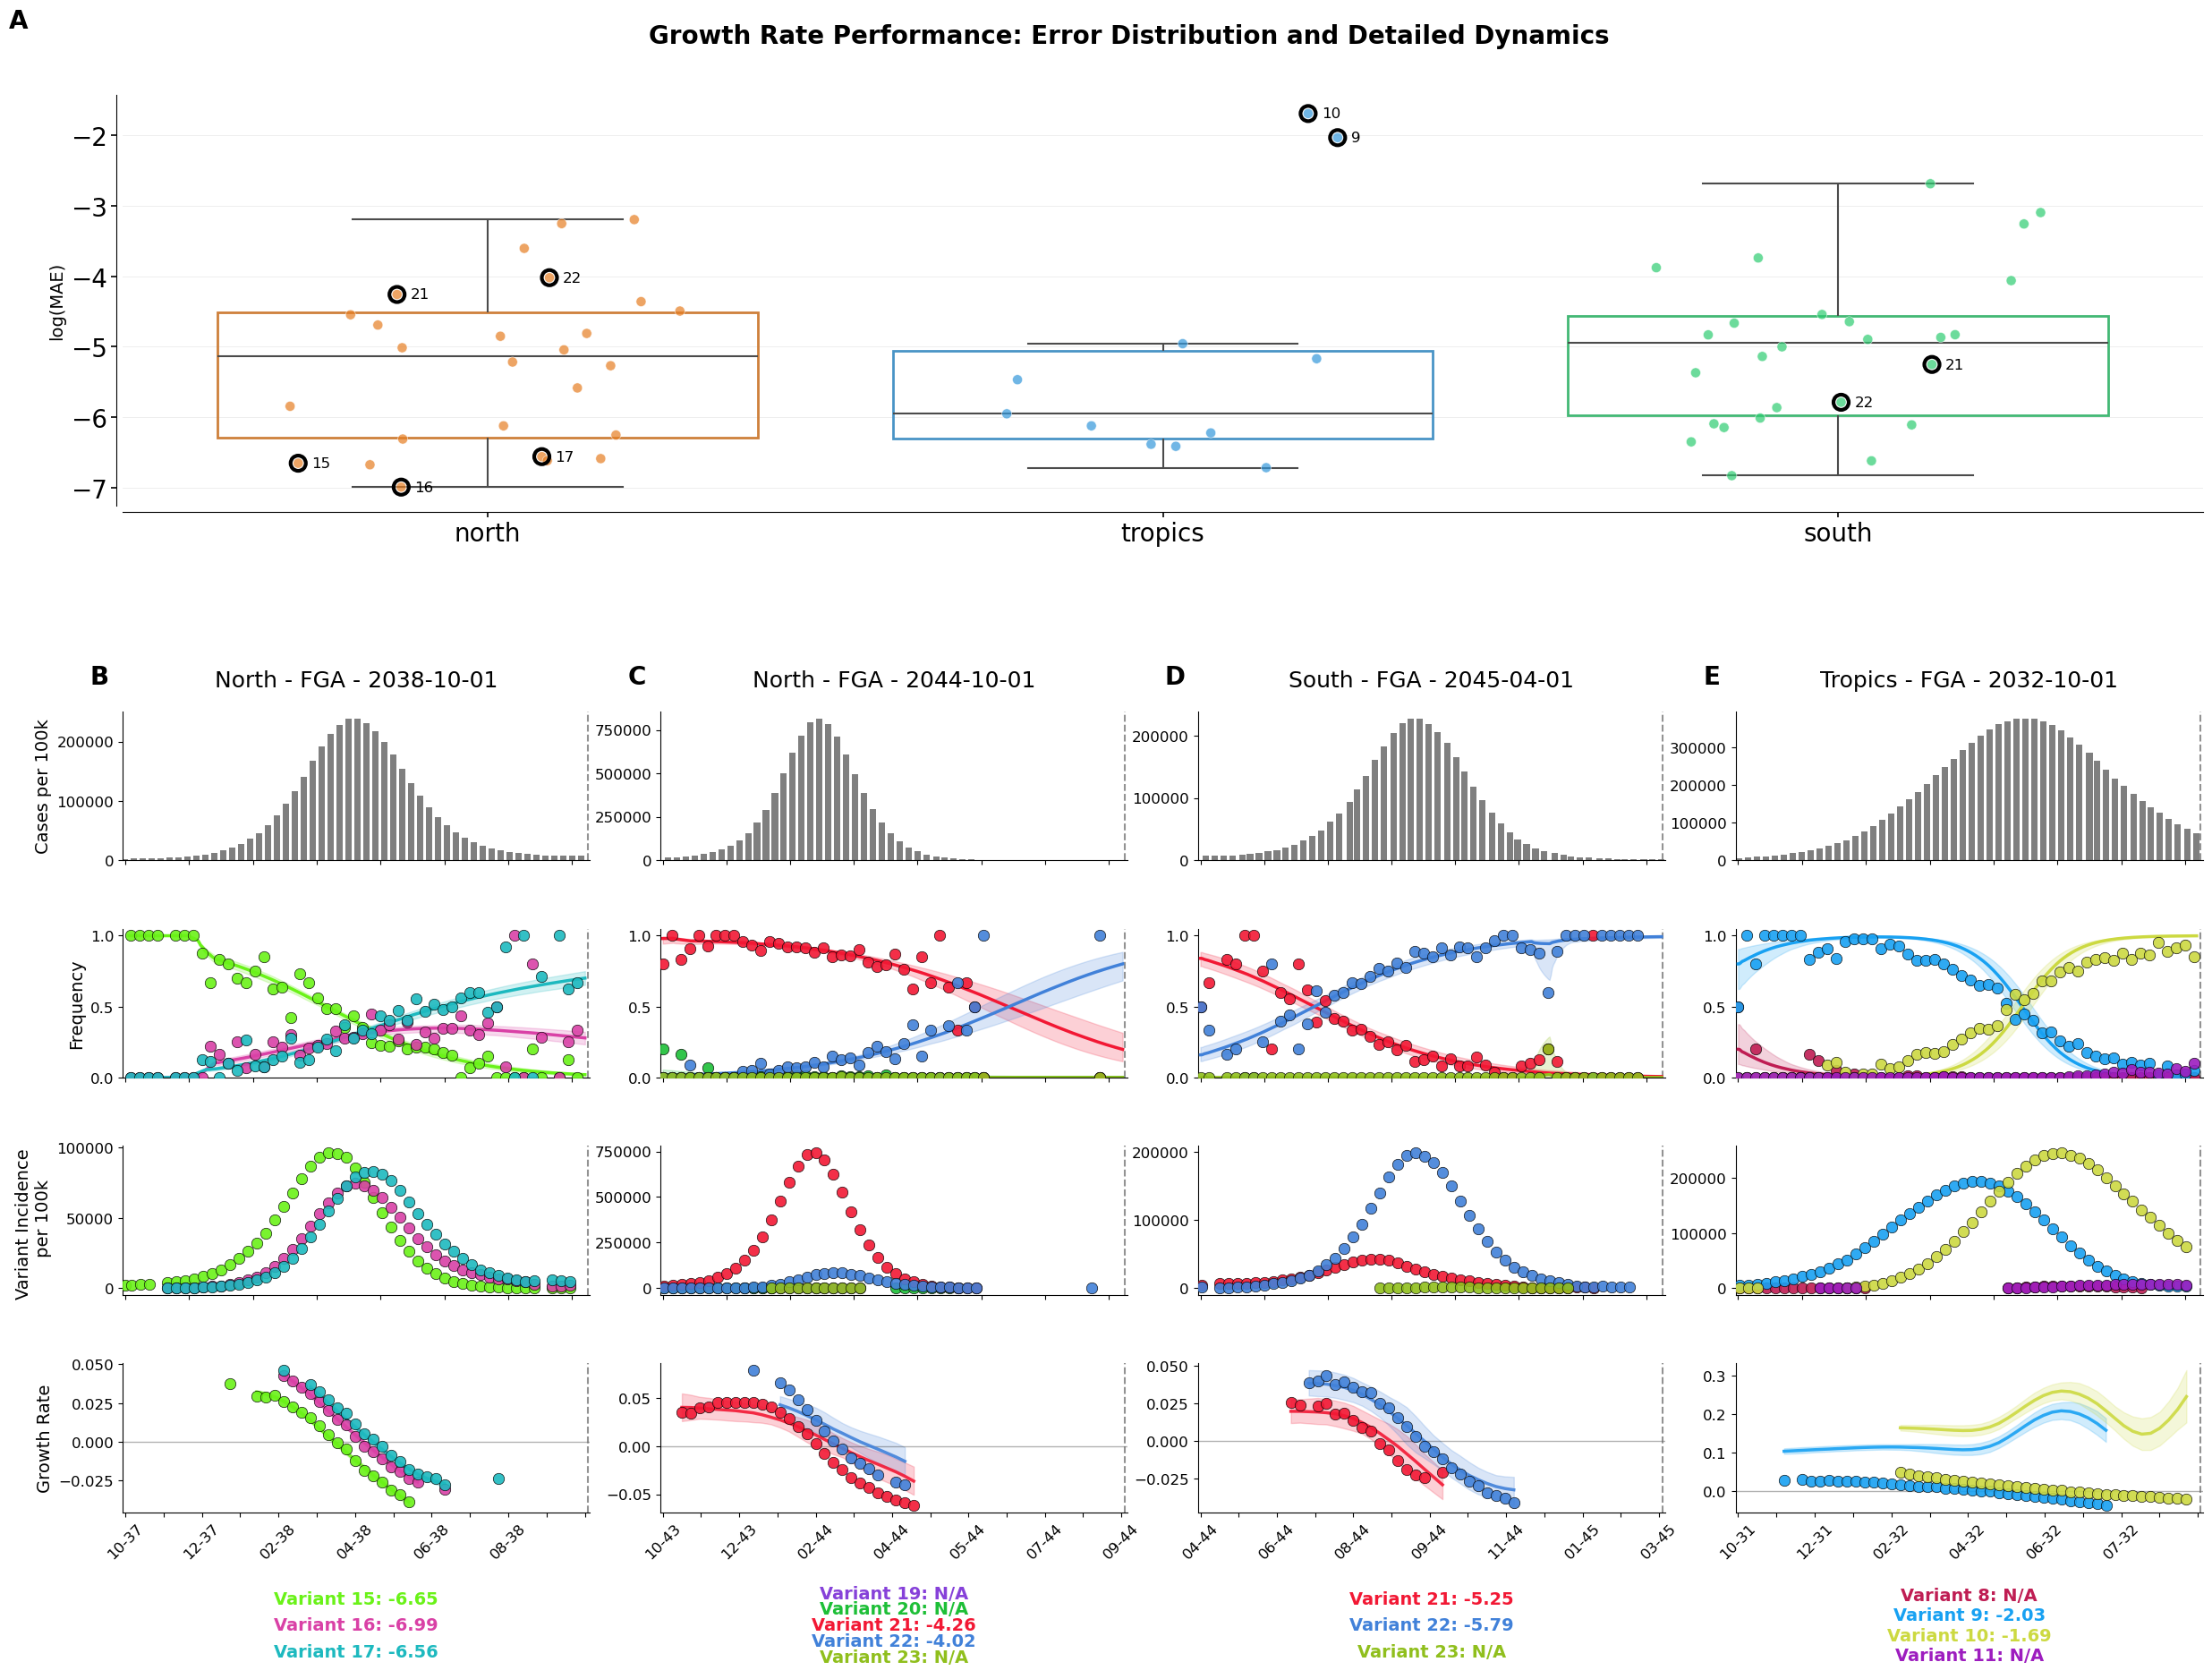

In [6]:
# FGA figure, ORIGINAL windows (E = tropics 2032-10-01). FGA's variational inference did NOT
# converge at E (final_loss=NaN), so E is normally filtered out of the boxplot. We deliberately
# include it here and circle it: a non-converged fit whose frequency nowcast looks deceptively
# good while its growth-rate inference is catastrophic (r^2 ~ -50 to -90).
fga_save_path = '../../antigen-tex/reviews/round1/figures/figureS6_combined_growth_rate_figure_fga'
window_specs = [
    {'pivot_date': '2038-10-01', 'location': 'north',   'model': 'FGA'},  # B
    {'pivot_date': '2044-10-01', 'location': 'north',   'model': 'FGA'},  # C
    {'pivot_date': '2045-04-01', 'location': 'south',   'model': 'FGA'},  # D
    {'pivot_date': '2032-10-01', 'location': 'tropics', 'model': 'FGA'},  # E (non-converged; included on purpose)
]
# Add the selected windows' FGA rows (converged or not) to the converged boxplot data so every
# selected variant is present to be circled -- this is what surfaces the non-converged E points.
_sel = {(w['pivot_date'], w['location']) for w in window_specs}
_extra = variant_growth_rate_errors_all[
    (variant_growth_rate_errors_all['model'] == 'FGA')
    & variant_growth_rate_errors_all.apply(lambda r: (r['pivot_date'], r['location']) in _sel, axis=1)
]
fga_errors_for_fig = pd.concat([variant_growth_rate_errors_df, _extra]).drop_duplicates(
    subset=['model', 'pivot_date', 'location', 'variant']
)
plot_combined_growth_rate_figure(
    fga_errors_for_fig, window_specs, build, color_map, deme_palette, model="FGA",
)
plt.savefig(f'{fga_save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{fga_save_path}.png', dpi=300, bbox_inches='tight')
print(f"Saved {fga_save_path}.pdf  (original E, non-converged, circled)")
plt.show()


Saved ../../antigen-tex/reviews/round1/figures/figureS6_combined_growth_rate_figure_fga_altE.pdf  (replacement E = south 2030-04-01)


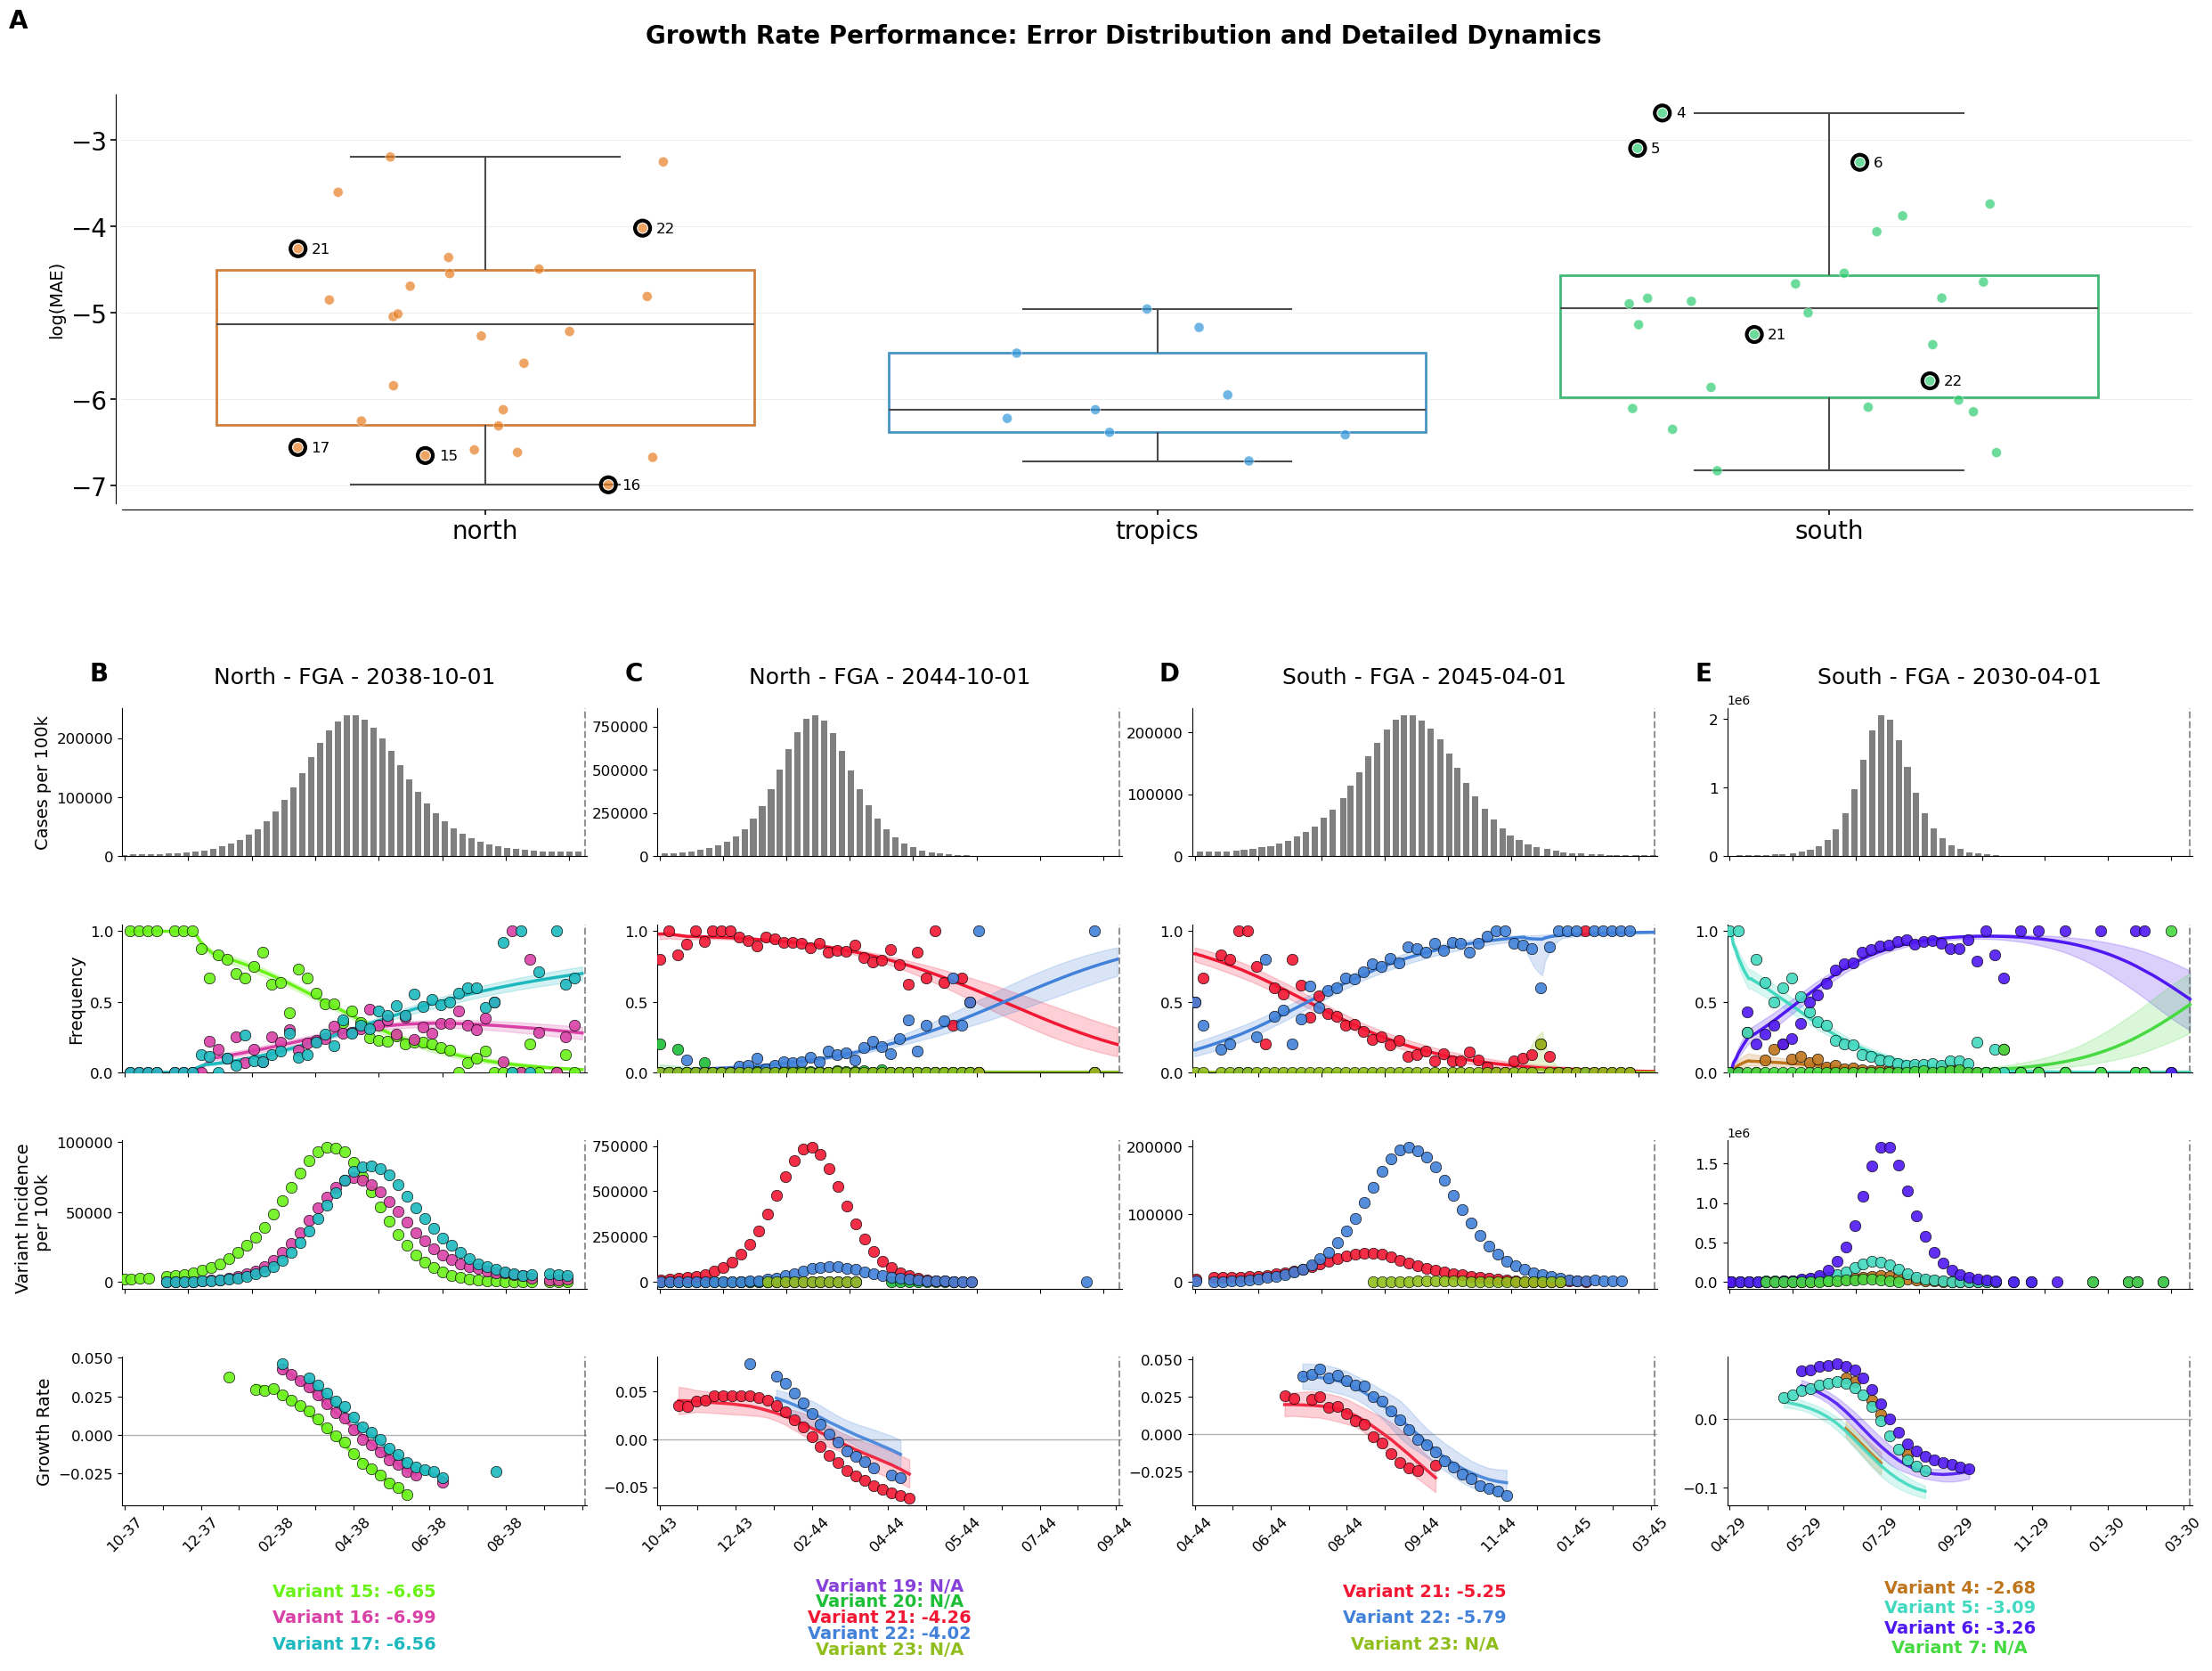

In [7]:
# FGA figure, REPLACEMENT E. Default = the highest-error CONVERGED FGA window; swap to
# ('2037-10-01','tropics') to keep E's deme.
REPLACEMENT_E = {'pivot_date': '2030-04-01', 'location': 'south', 'model': 'FGA'}
fga_alt_save_path = '../../antigen-tex/reviews/round1/figures/figureS6_combined_growth_rate_figure_fga_altE'
window_specs = [
    {'pivot_date': '2038-10-01', 'location': 'north', 'model': 'FGA'},  # B
    {'pivot_date': '2044-10-01', 'location': 'north', 'model': 'FGA'},  # C
    {'pivot_date': '2045-04-01', 'location': 'south', 'model': 'FGA'},  # D
    REPLACEMENT_E,                                                      # E (replacement)
]
plot_combined_growth_rate_figure(
    variant_growth_rate_errors_df, window_specs, build, color_map, deme_palette, model="FGA",
)
plt.savefig(f'{fga_alt_save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{fga_alt_save_path}.png', dpi=300, bbox_inches='tight')
print(f"Saved {fga_alt_save_path}.pdf  (replacement E = {REPLACEMENT_E['location']} {REPLACEMENT_E['pivot_date']})")
plt.show()
